# CDR3 Graph Analysis

In [1]:
import sys
import time
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb_path = find_airr_benchmark_vdjdb_slim(benchmark_root)

vdjdb = pd.read_csv(vdjdb_path, sep='\t')
vdjdb = vdjdb[vdjdb['gene'].eq('TRB')].copy()
print(f'Loaded VDJdb snapshot from: {vdjdb_path}')
print(vdjdb.head())
vdjdb['antigen.epitope'].value_counts().head(20)

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 2071.60it/s]


Loaded VDJdb snapshot from: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb.slim.txt.gz
      gene             cdr3      species antigen.epitope antigen.gene  \
50093  TRB     ATSIRFTDTQYF  HomoSapiens     PQPELPYPQPQ      Gliadin   
50094  TRB  CAAADEEIGNQPQHF  HomoSapiens       ATDALMTGY          NS3   
50095  TRB    CAAAERNTGELFF  HomoSapiens       YLQPRTFLL        Spike   
50096  TRB   CAAAGTASTDTQYF  HomoSapiens        RAKFKQLL        BZLF1   
50097  TRB      CAAAQGYEQYF  HomoSapiens       NLVPMVATV         pp65   

        antigen.species   complex.id       v.segm      j.segm           mhc.a  \
50093  TriticumAestivum            0   TRBV7-2*01  TRBJ2-3*01  HLA-DQA1*05:01   
50094               HCV            0  TRBV10-3*01  TRBJ1-5*01     HLA-A*01:01   
50095        SARS-CoV-2            0    TRBV28*01  TRBJ2-2*01        HLA-A*02   
50096               EBV  80505,80553  TRBV10-3*01  TRBJ2-3*01     HLA-B*08:01   
50097               CMV  

antigen.epitope
SLLMWITQV         29698
NLVPMVATV         13044
KLGGALQAK         12667
GILGFVFTL          5236
VEALYLVCG          2545
AVFDRKSDAK         1648
ELAGIGILTV         1431
RAKFKQLL           1410
GLCTLVAML          1227
YLQPRTFLL           903
LLAGIGTVPI          885
VEALYLVSG           853
IVTDFSVIK           551
SPRWYFYYL           545
CTPYDINQM           530
TTPESANL            523
KRWIILGLNK          469
TFEYVSQPFLMDLE      445
TTDPSFLGRY          438
YVLDHLIVV           435
Name: count, dtype: int64

In [3]:
def get_seqs(epitopes: list[str], size: int = 500, gene: str = 'TRB') -> pd.DataFrame:
    rows = vdjdb[vdjdb['gene'].eq(gene) & vdjdb['antigen.epitope'].isin(epitopes)].copy()
    sampled_parts = []
    for epitope, grp in rows.groupby('antigen.epitope'):
        n_take = min(size, len(grp))
        sampled = grp.sample(n=n_take, random_state=42).copy()
        sampled['antigen.epitope'] = epitope
        sampled_parts.append(sampled)
    if not sampled_parts:
        return pd.DataFrame(columns=['junction_aa', 'antigen.epitope'])
    sampled = pd.concat(sampled_parts, ignore_index=True).drop_duplicates(subset=['cdr3'])
    return sampled[['cdr3', 'antigen.epitope']].rename(columns={'cdr3': 'junction_aa'})

epitopes = ['GLCTLVAML', 'GILGFVFTL', 'NLVPMVATV']
df_epi = get_seqs(epitopes=epitopes, size=1000)
print(df_epi['antigen.epitope'].value_counts())
print('Unique CDR3:', df_epi['junction_aa'].nunique())

antigen.epitope
GILGFVFTL    1000
NLVPMVATV     999
GLCTLVAML     991
Name: count, dtype: int64
Unique CDR3: 2990


In [4]:
clonotypes = [
    Clonotype(
        sequence_id=str(i),
        locus='TRB',
        junction_aa=aa,
        v_gene='TRBV7-9*01',
        j_gene='TRBJ2-1*01',
        duplicate_count=1,
        _validate=False,
    )
    for i, aa in enumerate(df_epi['junction_aa'].tolist())
]

start = time.perf_counter()
g_serial = build_edit_distance_graph(clonotypes, metric='hamming', threshold=1, n_jobs=1)
t_serial = time.perf_counter() - start
print('Serial hamming runtime:', round(t_serial, 3), 's')

start = time.perf_counter()
g_parallel = build_edit_distance_graph(clonotypes, metric='hamming', threshold=1, n_jobs=4)
t_parallel = time.perf_counter() - start
print('Parallel (n_jobs=4) hamming runtime:', round(t_parallel, 3), 's')
if t_parallel > 0:
    print('Speedup:', round(t_serial / t_parallel, 2), 'x')

assert g_serial.ecount() == g_parallel.ecount()
graph = g_parallel
print('Vertices:', graph.vcount(), 'Edges:', graph.ecount())

Serial hamming runtime: 0.024 s
Parallel (n_jobs=4) hamming runtime: 0.699 s
Speedup: 0.03 x
Vertices: 2990 Edges: 623


In [5]:
start = time.perf_counter()
layout = graph.layout_graphopt(niter=2000, node_charge=0.005)
elapsed = time.perf_counter() - start
components = graph.components()
print('Layout runtime:', round(elapsed, 3), 's')
print('Connected components:', len(components))
print('Largest CC size:', max(components.sizes()) if components.sizes() else 0)

Layout runtime: 13.318 s
Connected components: 2567
Largest CC size: 65


In [6]:
coords = pd.DataFrame(layout.coords, columns=['x', 'y'])
df_graph = pd.DataFrame({
    'sequence_id': [str(i) for i in range(graph.vcount())],
    'junction_aa': graph.vs['name'],
    'component_id': graph.components().membership,
    'degree': graph.degree(),
})
df_graph = pd.concat([df_graph, coords], axis=1)
print(df_graph.head())

  sequence_id         junction_aa  component_id  degree            x  \
0           0    CASSPRQGWSQETQYF             0       0   155.258725   
1           1       CASSIFTIEPQHF             1       0  2149.337980   
2           2     CASRSLAGVWDTQYF             2       0 -1865.438792   
3           3  CASSLTVAGVYPGYEQYF             3       0   570.034547   
4           4       CASSNRAAYEQYF             4       2   189.368538   

             y  
0 -1628.652703  
1  1060.827105  
2  1907.806835  
3 -1545.001037  
4  -581.309526  


In [7]:
df_graph_summary = (
    df_graph.groupby('component_id', as_index=False)
    .agg(
        cluster_size=('component_id', 'size'),
        x_mean=('x', 'mean'),
        y_mean=('y', 'mean'),
        mean_degree=('degree', 'mean'),
    )
)
print(df_graph_summary.head(10))

   component_id  cluster_size       x_mean       y_mean  mean_degree
0             0             1   155.258725 -1628.652703     0.000000
1             1             1  2149.337980  1060.827105     0.000000
2             2             1 -1865.438792  1907.806835     0.000000
3             3             1   570.034547 -1545.001037     0.000000
4             4            65   -89.262167   -36.928518     3.692308
5             5             1 -1527.971416 -1583.137983     0.000000
6             6             1 -1491.866853   428.269744     0.000000
7             7             1  2846.946474   434.944354     0.000000
8             8             2  1741.931532   360.999150     1.000000
9             9             1  2053.033318  2116.165059     0.000000


In [8]:
df_annot = df_epi.drop_duplicates(subset=['junction_aa'])
df_plot = (
    df_graph.merge(df_graph_summary, on='component_id', how='left')
    .merge(df_annot, on='junction_aa', how='left')
)
print(df_plot.head())

  sequence_id         junction_aa  component_id  degree            x  \
0           0    CASSPRQGWSQETQYF             0       0   155.258725   
1           1       CASSIFTIEPQHF             1       0  2149.337980   
2           2     CASRSLAGVWDTQYF             2       0 -1865.438792   
3           3  CASSLTVAGVYPGYEQYF             3       0   570.034547   
4           4       CASSNRAAYEQYF             4       2   189.368538   

             y  cluster_size       x_mean       y_mean  mean_degree  \
0 -1628.652703             1   155.258725 -1628.652703     0.000000   
1  1060.827105             1  2149.337980  1060.827105     0.000000   
2  1907.806835             1 -1865.438792  1907.806835     0.000000   
3 -1545.001037             1   570.034547 -1545.001037     0.000000   
4  -581.309526            65   -89.262167   -36.928518     3.692308   

  antigen.epitope  
0       GILGFVFTL  
1       GILGFVFTL  
2       GILGFVFTL  
3       GILGFVFTL  
4       GILGFVFTL  


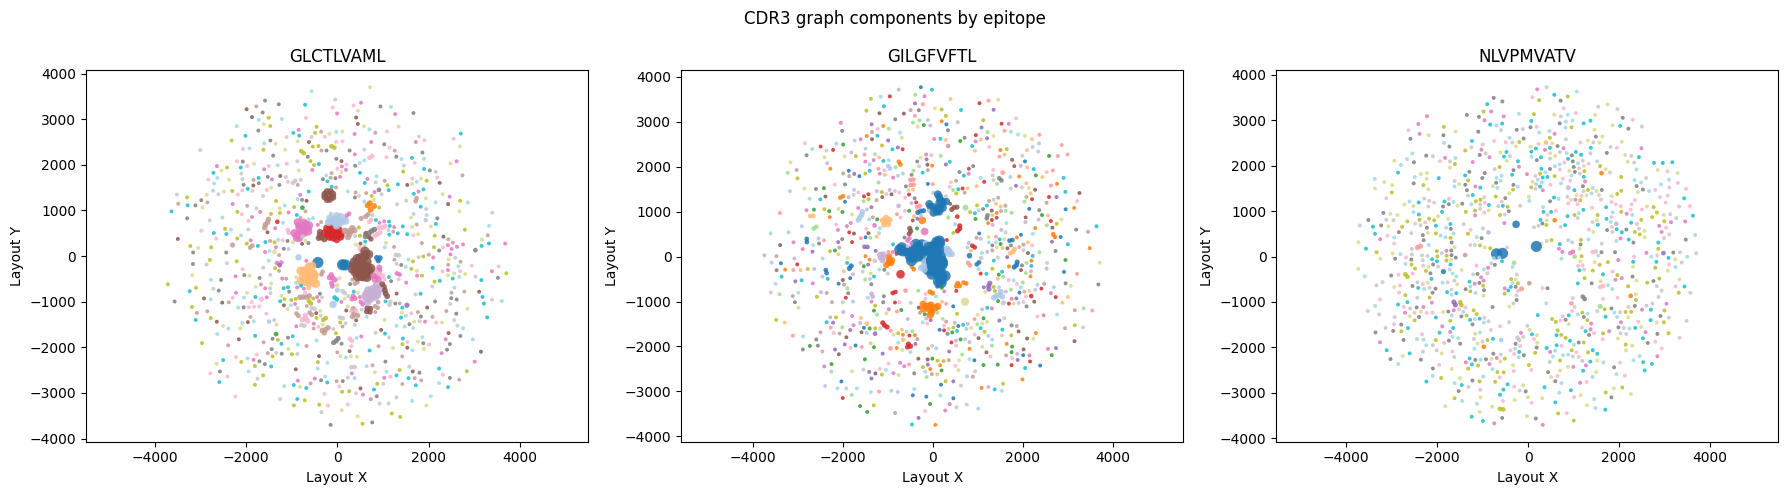

In [9]:
fig, axes = plt.subplots(1, len(epitopes), figsize=(6 * len(epitopes), 5), squeeze=False)
for ax, epitope in zip(axes[0], epitopes):
    sub = df_plot[df_plot['antigen.epitope'].eq(epitope)].copy()
    if sub.empty:
        ax.set_title(f'{epitope} (no data)')
        ax.axis('off')
        continue
    sizes = (sub['cluster_size'].clip(lower=1) ** 0.5) * 8
    sc = ax.scatter(
        sub['x'],
        sub['y'],
        c=sub['component_id'],
        s=sizes,
        cmap='tab20',
        alpha=0.85,
        linewidth=0,
    )
    ax.set_title(epitope)
    ax.set_xlabel('Layout X')
    ax.set_ylabel('Layout Y')
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('CDR3 graph components by epitope', fontsize=12)
plt.tight_layout()
plt.show()